# Многокритериальная оптимизация

## Постановка задачи

Рассмотрим на примере сравнение одно- и многокритериальной оптимизации.

Допустим, имеется типичная задача: есть поле (настоящее поле, с травой), состоящее из двух половин. На одной половине растет пшеница, вторая половина не засеяна.

Мы перемещаемся на автомобиле, и нам необходимо попасть из нижнего левого угла поля в правый верхний угол.

![Meadow](https://github.com/alsprogrammer/optimization_course/blob/master/Diagram1.png?raw=1 "Поле")

От того, где будет выбрана точка пересечения двух полей, зависит время движения.

Это как раз тот случай, когда кратчайший путь не является оптимальным. На первый взгляд кажется, что самый быстрый путь - кратчайший, по диагонали. Однако следует учитывать, что скорость движения и расход топлива рразные: когда автомобиль двигается по незасеянному участку, его максимальная скорость составляет 40 км/ч, а когда по засеянному пшеницей - 30 км/ч. Расход топлива при движении по засеянной половине составляет 15 л/100 км, а по незасеянной - 11,5 л/100 км.

Очевидно, что задач оптимизации тут как минимум две:

* минимизировать время проезда поля
* минимизировать расход топлива на проезд поля

Эти задачи и называются критериями оптимизации, а сами задачи такого типа - задачами многокритериальной оптимизации.

Обозначим время пересечения поля за $T$, а расход топлива - за $V$.

## Способы решения

Существует несколько методов решения задачи многокритериальной оптимизации. Рассмотрим их:

### Метод аддитивной свертки критериев

В этом методе предполагается, что каждый из критериев для нас важен, и мы можем указать, какой из них важнее, а какой менее важен, в числовом виде.

В этом случае предполагается, что каждому из критериев назначаются веса (числа от 0 до единицы), причем все веса в сумме будут равны единице.

Обозначим веса через $\alpha$, тогда получим следующий общий критерий оптимизации, объединяющий оба вышеприведенных:

$$
f = \alpha_T \cdot T + \alpha_V \cdot V \\
\alpha_T + \alpha_V = 1 \\
$$
Естественно, этот подход может быть легко расширен для сучая, когда количество критериев больше двух.

### Дискриминационный метод

В этом случае мы предполагаем, что оптимизировать (в нашем случае минимизировать) мы будем только один критерий, а на второй (или остальные, если всего критериев больше двух) установим ограничения.

Например, в нашем случае с автомобилем и полем мы можем потребовать, чтобы пересечение поля заняло не более 20 минут, но расход топлива при этом был минимальным.

В математическом виде задача при этом будет выглядеть следующим образом:

$$
f = T \\
\alpha_T < 20
$$


## Математическое описание

Попробуем теперь рассмотреть,как это все работает в нашей среде.

Для начала выразим нашу задачу математическим языком, и начнем с геометрии. Пусть нам даны следующие величины:

$h_1$ - высота поля с незасеянной частью,

$h_2$ - высота поля с частью, засеянной пшеницей,

$l$ - ширина поля,

$x$ - расстояние от левого края поля до точки пересечения.

Тогда путь автомобиля по части поля, засеянной пшеницей, легко определить из формулы Пифагора:

$$
L_1 = \sqrt{h_1^2 + x^2}
$$

как и путь по незасеянной части поля:

$$
L_2 = \sqrt{h_2^2 + (l - x)^2}
$$

Отсюда время, необходимое для проезда по засеянной части, считая, что скорость движения по ней обозначена $v_1$, равно

$$
t_1 = \frac{L_1}{v_1}
$$

и для незасеянной части (скорость движения по которой, соответственно,$v_2$)

$$
t_2 = \frac{L_2}{v_2}
$$

Таким образом, общее время движения будет равно

$$
T = t_1 + t_2 = \frac{L_1}{v_1} + \frac{L_2}{v_2} = \frac{\sqrt{h_1^2 + x^2}}{v_1} + \frac{\sqrt{h_2^2 + (l - x)^2}}{v_2}
$$

Для затрат топлива, считая, что расход топлива по незасеянному участку мы обозначим через $c_1$, а по засеянному $c_2$, формула будет выглядеть следующим образом:

$$
V = L_1 \cdot c_1 + L_2 \cdot c_2 = \sqrt{h_1^2 + x^2} \cdot c_1 + \sqrt{h_2^2 + (l - x)^2} \cdot c_2
$$

## Решение задачи

Для решения попробуем применить функции оптимизации, имеющиеся в пакете `scipy`, а именно, `minimize`.

Используем следующий код:

In [1]:
import math  #
from scipy.optimize import minimize  # берем готовую библиотечную функцию minimize

# задаим исходные данные в километрах

h1 = 0.10  # 100 метров
h2 = 0.10  # 100 метров
l = 1  # 1000 метров

v1 = 40  # 40 км/ч
v2 = 30  # 30 км/ч

c1 = 0.115  # л/км
c2 = 0.15  # л/км

# описываем функцию, которую хотим минимизировать

def func_to_minimize(x):
    t1 = math.sqrt(h1 * h1 + x * x) / v1
    t2 = math.sqrt(h2 * h2 + (l - x) * (l - x)) / v2
    return t1 + t2

# Зададим начальное значение x, пусть это будет самое начало поля, т.е., вначале мы поедем вериткально вверх,
# а затем, как только достигнем конца засеянной части, кратчайшим путем поедем в правый верхний угол поля
x = 0

# а теперь минимизируем нашу функцию
result = minimize(func_to_minimize, x)
print(result)  # выведем наш результа на экран

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.027345206768001642
        x: [ 8.881e-01]
      nit: 8
      jac: [-8.195e-06]
 hess_inv: [[ 1.047e+01]]
     nfev: 24
     njev: 12


/tmp/ipykernel_8345/441417220.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t1 = math.sqrt(h1 * h1 + x * x) / v1
/tmp/ipykernel_8345/441417220.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t2 = math.sqrt(h2 * h2 + (l - x) * (l - x)) / v2


Как можно видеть, результат состоит из нескольких элементов (говоря языком программистов, объект-результат имеет несколько свойств).

Нас интересуют несколько из них: `success` - успешно ли закончилась оптимизация. В нашем случае - `True`, то есть да, закончилось успешно, `fun` - оптимальное (минимальное в нашем случае) значение функции. Равно 0.0027, именно столько займет наша поездка в часах, `x` - найденное значение $x$, в нашем случае - 0.88 километра, или почти 900 метров от левого края поля. Именно в этой точке мы должны пересечь границу засеянной и незасеянной частей.

Обратите внимание, что `x` представляет собой массив (`array`). Так произошло потому, что несмотря на то, что оптимимзация у нас ведется по одному параметру $x$, выполнять ее можно по нескольким параметрам, в этом случае `x` будет состоять из нескольких значений.

## Задание для самостоятельной работы

В следующей ячейке изменить целевую фукнцию таким образом, чтобы оптимизировать расход топлива.

In [2]:
import math  #
from scipy.optimize import minimize  # берем готовую библиотечную функцию minimize

# задаим исходные данные в километрах

h1 = 0.10  # 100 метров
h2 = 0.10  # 100 метров
l = 1  # 1000 метров

v1 = 40  # 40 км/ч
v2 = 30  # 30 км/ч

c1 = 0.115  # л/км
c2 = 0.15  # л/км

a1 = 0.5  # вес первого критерия, т.е. времени движения
a2 = 0.5  # вес второго критерия, т.е. расхода топлива

# описываем функцию, которую хотим минимизировать

def func_to_minimize(x):
    # Длина первого участка
    length1 = math.sqrt(h1 * h1 + x * x)
    # Длина второго участка
    length2 = math.sqrt(h2 * h2 + (l - x) * (l - x))

    # Расход топлива = длина × расход на км
    fuel1 = length1 * c1
    fuel2 = length2 * c2

    return fuel1 + fuel2

# Зададим начальное значение x, пусть это будет самое начало поля, т.е., вначале мы поедем вериткально вверх,
# а затем, как только достигнем конца засеянной части, кратчайшим путем поедем в правый верхний угол поля
x = 0

# а теперь минимизируем нашу функцию
result = minimize(func_to_minimize, x)
print(result)  # выведем наш результа на экран

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.12528088930803516
        x: [ 8.824e-01]
      nit: 10
      jac: [-5.029e-08]
 hess_inv: [[ 2.454e+00]]
     nfev: 24
     njev: 12


/tmp/ipykernel_8345/3738595798.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  length1 = math.sqrt(h1 * h1 + x * x)
/tmp/ipykernel_8345/3738595798.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  length2 = math.sqrt(h2 * h2 + (l - x) * (l - x))


В следующей ячейке изменить целевую фукнцию таким образом, чтобы оптимизация превратилась в многокритериальную с аддитивной сверткой критериев.

In [3]:
import math  #
from scipy.optimize import minimize  # берем готовую библиотечную функцию minimize

# задаим исходные данные в километрах

h1 = 0.10  # 100 метров
h2 = 0.10  # 100 метров
l = 1  # 1000 метров

v1 = 40  # 40 км/ч
v2 = 30  # 30 км/ч

c1 = 0.115  # л/км
c2 = 0.15  # л/км

a1 = 0.5  # вес первого критерия, т.е. времени движения
a2 = 0.5  # вес второго критерия, т.е. расхода топлива

# описываем функцию, которую хотим минимизировать

def func_to_minimize(x):
    # Длины участков
    length1 = math.sqrt(h1*h1 + x*x)
    length2 = math.sqrt(h2*h2 + (l-x)*(l-x))

    # КРИТЕРИЙ 1: время в пути (часы)
    time1 = length1 / v1
    time2 = length2 / v2
    total_time = time1 + time2

    # КРИТЕРИЙ 2: расход топлива (литры)
    fuel1 = length1 * c1
    fuel2 = length2 * c2
    total_fuel = fuel1 + fuel2

    # НОРМИРОВКА (чтобы критерии были сопоставимы)
    # Оцениваем значения в крайних точках x=0 и x=l
    time_at_0 = math.sqrt(h1*h1 + 0)/v1 + math.sqrt(h2*h2 + l*l)/v2
    time_at_l = math.sqrt(h1*h1 + l*l)/v1 + math.sqrt(h2*h2 + 0)/v2
    fuel_at_0 = math.sqrt(h1*h1 + 0)*c1 + math.sqrt(h2*h2 + l*l)*c2
    fuel_at_l = math.sqrt(h1*h1 + l*l)*c1 + math.sqrt(h2*h2 + 0)*c2

    # Нормируем к диапазону [0,1]
    time_norm = (total_time - min(time_at_0, time_at_l)) / (max(time_at_0, time_at_l) - min(time_at_0, time_at_l))
    fuel_norm = (total_fuel - min(fuel_at_0, fuel_at_l)) / (max(fuel_at_0, fuel_at_l) - min(fuel_at_0, fuel_at_l))

    # Аддитивная свертка с весами
    return a1 * time_norm + a2 * fuel_norm

# Зададим начальное значение x, пусть это будет самое начало поля, т.е., вначале мы поедем вериткально вверх,
# а затем, как только достигнем конца засеянной части, кратчайшим путем поедем в правый верхний угол поля
x = 0

# а теперь минимизируем нашу функцию
result = minimize(func_to_minimize, x)
print(result)  # выведем наш результа на экран

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.15727165432596799
        x: [ 8.853e-01]
      nit: 8
      jac: [-5.588e-09]
 hess_inv: [[ 7.676e-02]]
     nfev: 20
     njev: 10


/tmp/ipykernel_8345/2501390452.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  length1 = math.sqrt(h1*h1 + x*x)
/tmp/ipykernel_8345/2501390452.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  length2 = math.sqrt(h2*h2 + (l-x)*(l-x))


### Дополнительное (необязательное) задание

Постройте график зависимости величины $x$ от величины $\alpha_1$

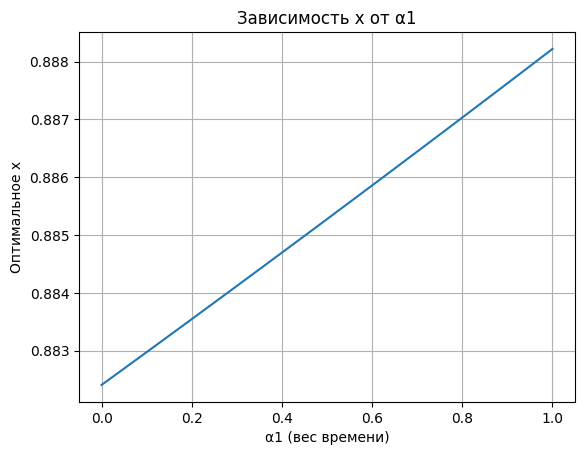

In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

h1 = 0.10
h2 = 0.10
l = 1

v1 = 40
v2 = 30

c1 = 0.115
c2 = 0.15

# функция с параметром a1
def func_to_minimize(x, a1):
    x = x[0]
    a2 = 1 - a1

    length1 = math.sqrt(h1*h1 + x*x)
    length2 = math.sqrt(h2*h2 + (l-x)*(l-x))

    total_time = length1 / v1 + length2 / v2
    total_fuel = length1 * c1 + length2 * c2

    # нормировка
    time_at_0 = math.sqrt(h1*h1)/v1 + math.sqrt(h2*h2 + l*l)/v2
    time_at_l = math.sqrt(h1*h1 + l*l)/v1 + math.sqrt(h2*h2)/v2

    fuel_at_0 = math.sqrt(h1*h1)*c1 + math.sqrt(h2*h2 + l*l)*c2
    fuel_at_l = math.sqrt(h1*h1 + l*l)*c1 + math.sqrt(h2*h2)*c2

    t_min, t_max = min(time_at_0, time_at_l), max(time_at_0, time_at_l)
    f_min, f_max = min(fuel_at_0, fuel_at_l), max(fuel_at_0, fuel_at_l)

    time_norm = (total_time - t_min) / (t_max - t_min)
    fuel_norm = (total_fuel - f_min) / (f_max - f_min)

    return a1 * time_norm + a2 * fuel_norm


# диапазон α1
a1_values = np.linspace(0, 1, 50)
x_values = []

for a1 in a1_values:
    result = minimize(func_to_minimize, [0.5], args=(a1,), bounds=[(0, l)])
    x_values.append(result.x[0])

# график
plt.figure()
plt.plot(a1_values, x_values)
plt.xlabel("α1 (вес времени)")
plt.ylabel("Оптимальное x")
plt.title("Зависимость x от α1")
plt.grid()

plt.show()


График демонстрирует чувствительность оптимального решения к весовым коэффициентам. При изменении приоритета критериев изменяется и оптимальная стратегия движения.